# Time Series Analysis

## Overview
This notebook integrates in-situ water quality data with Sentinel-2 derived spectral indices to perform long-term trend and cross-dataset correlation analysis across 2015–2024.

1. Load Data and Merge WQ + Spectral Indices
2. Mann-Kendall Trend Analysis — Water Quality
3. Mann-Kendall Trend Analysis — Spectral Indices
4. Cross-Correlation Analysis — Matched Pairs
5. Cross-Correlation Heatmap
6. Dual Time Series
7. Anomaly Plot

**Spectral data:** `spectral_indices_summary.csv` from `03_calculate_indices` \
**Merge method:** `merge_asof` with ±3 day tolerance — 387 matched pairs (22% match rate) \
**Note:** 2015–2016 L1C scenes processed without SCL cloud masking. EVI excluded (143/145 NaN values).

---

### Imports & Pip Install

In [51]:
import pandas as pd
from pandas import merge_asof
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
from scipy import stats
import pymannkendall as mk
from pymannkendall import original_test as mk_test
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns   

### Read Indices summary, load Pivot Table and GeoDataFrame 

In [28]:
df_indices = pd.read_csv("indices_summary.csv")
print(df_indices.head(2))

df_pivot = pd.read_csv("upper_keys_pivot.csv", parse_dates=["ActivityStartDate"])
df_pivot["ActivityStartDate"] = pd.to_datetime(df_pivot["ActivityStartDate"])
df_pivot = df_pivot.set_index("ActivityStartDate").sort_index()
display(df_pivot.head(2))

wq_gdf = gpd.read_parquet("water_quality.parquet")
display(wq_gdf.head())  

  tile_id                 time      NDVI      NDWI     NDAVI  EVI     SSSII  \
0  T17RNH  2015-11-13 16:00:52 -0.028805  0.153598 -0.226168  NaN  0.127616   
1  T17RNH  2016-03-02 15:54:02 -0.037907  0.181355 -0.248123  inf  0.147029   

       NDTI       DII  
0 -0.127616 -0.153930  
1 -0.147029 -0.142977  


,MonitoringLocationIdentifier,Secchi Depth (m),Salinity (PSS),Temperature (deg C),Turbidity (NTU)
ActivityStartDate,,,,,
2015-01-07,21FLDADE_WQX-BB47,NaN,33.746667,25.330000,0.5
2015-01-07,21FLDADE_WQX-BB50,NaN,30.970000,25.223333,0.8


,MonitoringLocationIdentifier,Secchi Depth (m),Salinity (PSS),Temperature (deg C),Turbidity (NTU),Latitude,Longitude,geometry
Date,,,,,,,,
2015-01-07,21FLDADE_WQX-BB47,NaN,33.746667,25.330000,0.5,25.336794,-80.320077,POINT (769962.142 153691.31)
2015-01-07,21FLDADE_WQX-BB50,NaN,30.970000,25.223333,0.8,25.229898,-80.376777,POINT (764611.659 141671.903)
2015-01-07,21FLDADE_WQX-BB51,NaN,30.806667,25.396667,0.4,25.251496,-80.414079,POINT (760789.398 143956.507)
2015-02-03,21FLSFWM_WQX-6598,2.5,35.000000,21.000000,1.8,25.174050,-80.423081,POINT (760133.028 135344.954)
2015-02-03,21FLSFWM_WQX-6599,1.6,32.800000,21.500000,2.2,25.206681,-80.440400,POINT (758285.307 138911.686)


### Load spectral indicies summary 

In [15]:
# Spectral indices summary
df_indices = pd.read_csv("indices_summary.csv", parse_dates=["time"])
df_indices = df_indices.set_index("time").sort_index()

print(f"Shape: {df_indices.shape}")
print(f"Date range: {df_indices.index.min()} to {df_indices.index.max()}")
print(f"\nColumns: {df_indices.columns.tolist()}")
print(f"\nNaN counts:\n{df_indices.isnull().sum()}")
display(df_indices.head())

Shape: (145, 8)
Date range: 2015-11-13 16:00:52 to 2024-12-05 16:05:11

Columns: ['tile_id', 'NDVI', 'NDWI', 'NDAVI', 'EVI', 'SSSII', 'NDTI', 'DII']

NaN counts:
tile_id      0
NDVI         1
NDWI         1
NDAVI        1
EVI        143
SSSII        0
NDTI         0
DII         92
dtype: int64


,tile_id,NDVI,NDWI,NDAVI,EVI,SSSII,NDTI,DII
time,,,,,,,,
2015-11-13 16:00:52,T17RNH,-0.028805,0.153598,-0.226168,NaN,0.127616,-0.127616,-0.153930
2015-11-13 16:00:52,T17RNJ,0.001099,0.111727,-0.171458,NaN,0.115901,-0.115901,-0.126511
2016-03-02 15:54:02,T17RNH,-0.037907,0.181355,-0.248123,inf,0.147029,-0.147029,-0.142977
2016-05-21 16:05:22,T17RNJ,-0.004456,0.082916,-0.119983,NaN,0.080308,-0.080308,-0.076728
2016-06-30 16:05:12,T17RNJ,-0.003134,0.075496,-0.109929,NaN,0.074221,-0.074221,-0.070902


## Analytical Approach
Mann-Kendall was selected over linear regression as it makes no assumptions about data normality and is robust to gaps and outliers — both common in environmental monitoring time series. The non-parametric Kruskal-Wallis test is used for seasonal comparisons for the same reason.

**Four datasets are used throughout this notebook:**
- **`df_pivot`** — raw WQ pivot table indexed by date, used for the ±3 day spectral merge
- **`df_wq_monthly`** — WQ data averaged monthly across all stations (119 months), used for Mann-Kendall and dual time series
- **`df_spec_monthly`** — spectral indices averaged monthly across both tiles (83 months), used for Mann-Kendall and dual time series  
- **`df_matched`** — 387 paired observations where both datasets have values within 3 days, used for correlation analysis and scatter plots

### Making spectral data useable with in-situ data

EVI must be dropped due to mostly NaN values. This is not unexpected as EVI (Enhanced Vegetation Index) was designed for desne terrestrial vegetetation.

Because Sentinel-2 works on a 5 day revisit interval and data from monitoring stations is not measured in fixed time intervals, a tolerance period (3 days) must be allowed to match Sentinel-2 overpass days temporaly with nearby water quality measuerments. 

In [21]:
df_indices = pd.read_csv("indices_summary.csv", parse_dates=["time"])
df_indices = df_indices.set_index("time").sort_index()

# Drop unusable band
df_indices = df_indices.drop(columns=["EVI"])

# Average tiles per day
index_cols = ["NDVI", "NDWI", "NDAVI", "SSSII", "NDTI", "DII"]

idx_daily = df_indices.groupby(df_indices.index.date)[index_cols].mean()
idx_daily.index = pd.to_datetime(idx_daily.index)
idx_daily.index.name = "date"

print(f"Shape after averaging tiles: {idx_daily.shape}")
print(f"Date range: {idx_daily.index.min()} to {idx_daily.index.max()}")
display(idx_daily.head())

# Reset index so everything is consistent
wq = wq_gdf.reset_index()

# --- FIX TIME COLUMN NAME (handles both cases safely) ---
if "ActivityStartDate" in wq.columns:
    wq["Date"] = pd.to_datetime(wq["ActivityStartDate"])
elif "Date" in wq.columns:
    wq["Date"] = pd.to_datetime(wq["Date"])
else:
    raise ValueError("No valid date column found in WQ data")

# Ensure geometry + numeric columns stay intact

idx = idx_daily.reset_index()
idx["date"] = pd.to_datetime(idx["date"])

wq_sorted = wq.sort_values("Date")
idx_sorted = idx.sort_values("date")

df_combined = merge_asof(
    wq_sorted,
    idx_sorted,
    left_on="Date",
    right_on="date",
    tolerance=pd.Timedelta("3 days"),
    direction="nearest"
)

if "date" in df_combined.columns:
    df_combined = df_combined.drop(columns=["date"])

    df_combined = df_combined.set_index("Date").sort_index()
df_combined.index.name = "Date"

matched = df_combined["NDVI"].notna().sum()
total = len(df_combined)

print(f"Total WQ rows: {total}")
print(f"Rows with spectral match: {matched} ({matched/total:.0%})")

df_combined.head()

Shape after averaging tiles: (101, 6)
Date range: 2015-11-13 00:00:00 to 2024-12-05 00:00:00


,NDVI,NDWI,NDAVI,SSSII,NDTI,DII
date,,,,,,
2015-11-13,-0.013853,0.132663,-0.198813,0.121758,-0.121758,-0.140220
2016-03-02,-0.037907,0.181355,-0.248123,0.147029,-0.147029,-0.142977
2016-05-21,-0.004456,0.082916,-0.119983,0.080308,-0.080308,-0.076728
2016-06-30,-0.011163,0.077989,-0.116710,0.068367,-0.068367,-0.079466
2016-07-20,-0.011372,0.089530,-0.134938,0.080036,-0.080036,-0.093898


Total WQ rows: 1749
Rows with spectral match: 387 (22%)


,MonitoringLocationIdentifier,Secchi Depth (m),Salinity (PSS),Temperature (deg C),Turbidity (NTU),Latitude,Longitude,geometry,NDVI,NDWI,NDAVI,SSSII,NDTI,DII
Date,,,,,,,,,,,,,,
2015-01-07,21FLDADE_WQX-BB47,NaN,33.746667,25.330000,0.5,25.336794,-80.320077,POINT (769962.142 153691.31),NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,21FLDADE_WQX-BB50,NaN,30.970000,25.223333,0.8,25.229898,-80.376777,POINT (764611.659 141671.903),NaN,NaN,NaN,NaN,NaN,NaN
2015-01-07,21FLDADE_WQX-BB51,NaN,30.806667,25.396667,0.4,25.251496,-80.414079,POINT (760789.398 143956.507),NaN,NaN,NaN,NaN,NaN,NaN
2015-02-03,21FLSFWM_WQX-6598,2.5,35.000000,21.000000,1.8,25.174050,-80.423081,POINT (760133.028 135344.954),NaN,NaN,NaN,NaN,NaN,NaN
2015-02-03,21FLSFWM_WQX-6599,1.6,32.800000,21.500000,2.2,25.206681,-80.440400,POINT (758285.307 138911.686),NaN,NaN,NaN,NaN,NaN,NaN


#### 387 matched readings (22%) across a 10 year span with a 3 days tolerance period. This is reasonable for correlation analysis. 


In [29]:
wq_cols       = ["Secchi Depth (m)", "Salinity (PSS)", 
                  "Temperature (deg C)", "Turbidity (NTU)"]
spectral_cols = ["NDVI", "NDWI", "NDAVI", "SSSII", "NDTI", "DII"]

# Dataset 1 — Full WQ time series (monthly mean across stations)
df_wq_monthly = df_pivot.copy()
df_wq_monthly["YearMonth"] = df_pivot.index.to_period("M")
df_wq_monthly = df_wq_monthly.groupby("YearMonth")[wq_cols].mean()
df_wq_monthly.index = df_wq_monthly.index.to_timestamp()
df_wq_monthly.index.name = "Date"

print(f"WQ monthly shape: {df_wq_monthly.shape}")
print(f"Date range: {df_wq_monthly.index.min()} to {df_wq_monthly.index.max()}")

# Dataset 2 — Full spectral index time series (monthly mean across tiles)
df_spec_monthly = idx_daily.copy()
df_spec_monthly["YearMonth"] = idx_daily.index.to_period("M")
df_spec_monthly = df_spec_monthly.groupby("YearMonth")[spectral_cols].mean()
df_spec_monthly.index = df_spec_monthly.index.to_timestamp()
df_spec_monthly.index.name = "Date"

print(f"\nSpectral monthly shape: {df_spec_monthly.shape}")
print(f"Date range: {df_spec_monthly.index.min()} to {df_spec_monthly.index.max()}")

# Dataset 3 — Matched pairs for correlation (387 rows)
df_matched = df_combined.dropna(subset=["NDVI"])[wq_cols + spectral_cols].copy()

print(f"\nMatched pairs shape: {df_matched.shape}")
print(f"Date range: {df_matched.index.min()} to {df_matched.index.max()}")

WQ monthly shape: (119, 4)
Date range: 2015-01-01 00:00:00 to 2024-12-01 00:00:00

Spectral monthly shape: (83, 6)
Date range: 2015-11-01 00:00:00 to 2024-12-01 00:00:00

Matched pairs shape: (387, 10)
Date range: 2016-05-23 00:00:00 to 2024-12-05 00:00:00


### Mann-Kendall Test

Used to detect whether a time series exhibits a consistent upward or downward trend over time. Evaluates the direction and strength of the trend using Kendall’s tau (τ) and determines its statistical significance with a p-value.

#### Mann-Kendall Trend Analysis: Water Quality

In [33]:
mk_wq_results = []

for col in wq_cols:
    series = df_wq_monthly[col].dropna()
    if len(series) < 10:
        print(f"SKIP {col} — not enough data")
        continue
    result = mk_test(series)
    mk_wq_results.append({
        "Parameter":   col,
        "Trend":       result.trend,
        "p-value":     round(result.p, 4),
        "Tau":         round(result.Tau, 4),
        "Sen Slope":   round(result.slope, 6),
        "Significant": result.p < 0.05
    })

df_mk_wq = pd.DataFrame(mk_wq_results)
print("=== Water Quality Trends ===")
print(df_mk_wq.to_string(index=False))

=== Water Quality Trends ===
          Parameter      Trend  p-value     Tau  Sen Slope  Significant
   Secchi Depth (m) increasing   0.0095  0.1631   0.005800         True
     Salinity (PSS)   no trend   0.0858 -0.1067  -0.030270        False
Temperature (deg C)   no trend   0.3417  0.0591   0.010013        False
    Turbidity (NTU)   no trend   0.3417 -0.0591  -0.002099        False


#### Mann-Kendall Trend Analysis: Spectral Indices

In [34]:
mk_spec_results = []

for col in spectral_cols:
    series = df_spec_monthly[col].dropna()
    if len(series) < 10:
        print(f"SKIP {col} — not enough data")
        continue
    result = mk_test(series)
    mk_spec_results.append({
        "Index":       col,
        "Trend":       result.trend,
        "p-value":     round(result.p, 4),
        "Tau":         round(result.Tau, 4),
        "Sen Slope":   round(result.slope, 6),
        "Significant": result.p < 0.05
    })

df_mk_spec = pd.DataFrame(mk_spec_results)
print("=== Spectral Index Trends ===")
print(df_mk_spec.to_string(index=False))

=== Spectral Index Trends ===
Index      Trend  p-value     Tau  Sen Slope  Significant
 NDVI increasing   0.0409  0.1531   0.000192         True
 NDWI   no trend   0.0623 -0.1396  -0.000242        False
NDAVI increasing   0.0305  0.1619   0.000428         True
SSSII   no trend   0.7891 -0.0203  -0.000030        False
 NDTI   no trend   0.7891  0.0203   0.000030        False
  DII   no trend   0.1517  0.1517   0.002610        False


c:\Users\ianra\miniconda3\Lib\site-packages\pymannkendall\pymannkendall.py:155: RuntimeWarning: invalid value encountered in subtract
  d[idx : idx + len(j)] = (x[j] - x[i]) / (j - i)


#### Correlation Analysis:

**Pearson correlation (r):** measures the strength and direction of  alinear relationship between values. Assumes normal distribution. \
**Spearman correlation (p, rho):** measures the strength and direction of a monotomic relationship based on ranked data. DOES NOT assume normal distribution. 

In [37]:
# Define the most ecologically meaningful pairs to test
pair_cols = [
    ("Turbidity (NTU)",   "NDTI",  "Turbidity vs NDTI"),
    ("Turbidity (NTU)",   "NDWI",  "Turbidity vs NDWI"),
    ("Secchi Depth (m)",  "NDWI",  "Secchi Depth vs NDWI"),
    ("Secchi Depth (m)",  "NDVI",  "Secchi Depth vs NDVI"),
    ("Secchi Depth (m)",  "NDAVI", "Secchi Depth vs NDAVI"),
    ("Salinity (PSS)",    "NDAVI", "Salinity vs NDAVI"),
]

corr_results = []

for wq_col, spec_col, label in pair_cols:
    paired = df_matched[[wq_col, spec_col]].dropna()
    if len(paired) < 10:
        print(f"SKIP {label} — not enough pairs")
        continue

    r, p = stats.pearsonr(paired[wq_col], paired[spec_col])
    rho, p_sp = stats.spearmanr(paired[wq_col], paired[spec_col])

    corr_results.append({
        "Pair":           label,
        "n":              len(paired),
        "Pearson r":      round(r, 3),
        "Pearson p":      round(p, 4),
        "Spearman rho":   round(rho, 3),
        "Spearman p":     round(p_sp, 4),
        "Significant":    p < 0.05
    })

df_corr = pd.DataFrame(corr_results)
print("=== WQ — Spectral Correlations ===")
print(df_corr.to_string(index=False))

=== WQ — Spectral Correlations ===
                 Pair   n  Pearson r  Pearson p  Spearman rho  Spearman p  Significant
    Turbidity vs NDTI 359     -0.133     0.0119        -0.129      0.0141         True
    Turbidity vs NDWI 359      0.325     0.0000         0.155      0.0032         True
 Secchi Depth vs NDWI 244     -0.205     0.0013        -0.186      0.0036         True
 Secchi Depth vs NDVI 244      0.091     0.1587        -0.015      0.8171        False
Secchi Depth vs NDAVI 244      0.176     0.0059         0.108      0.0930         True
    Salinity vs NDAVI 366      0.087     0.0964         0.061      0.2451        False


## Visualization 

### Define Parameters

In [42]:
param_cols = [col for col in wq_gdf.columns if any(p in col for p in 
              ["Temperature", "Salinity", "Turbidity", "Secchi", "Chlorophyll"])]

### Monthly Mean Time Series 

- Blue banding shows standard deviation. 

- **Narrow band** — readings were consistent that month across stations and time, conditions were stable \
- **Wide band** — high variability, meaning either different stations had very different readings, or conditions fluctuated a lot within the month

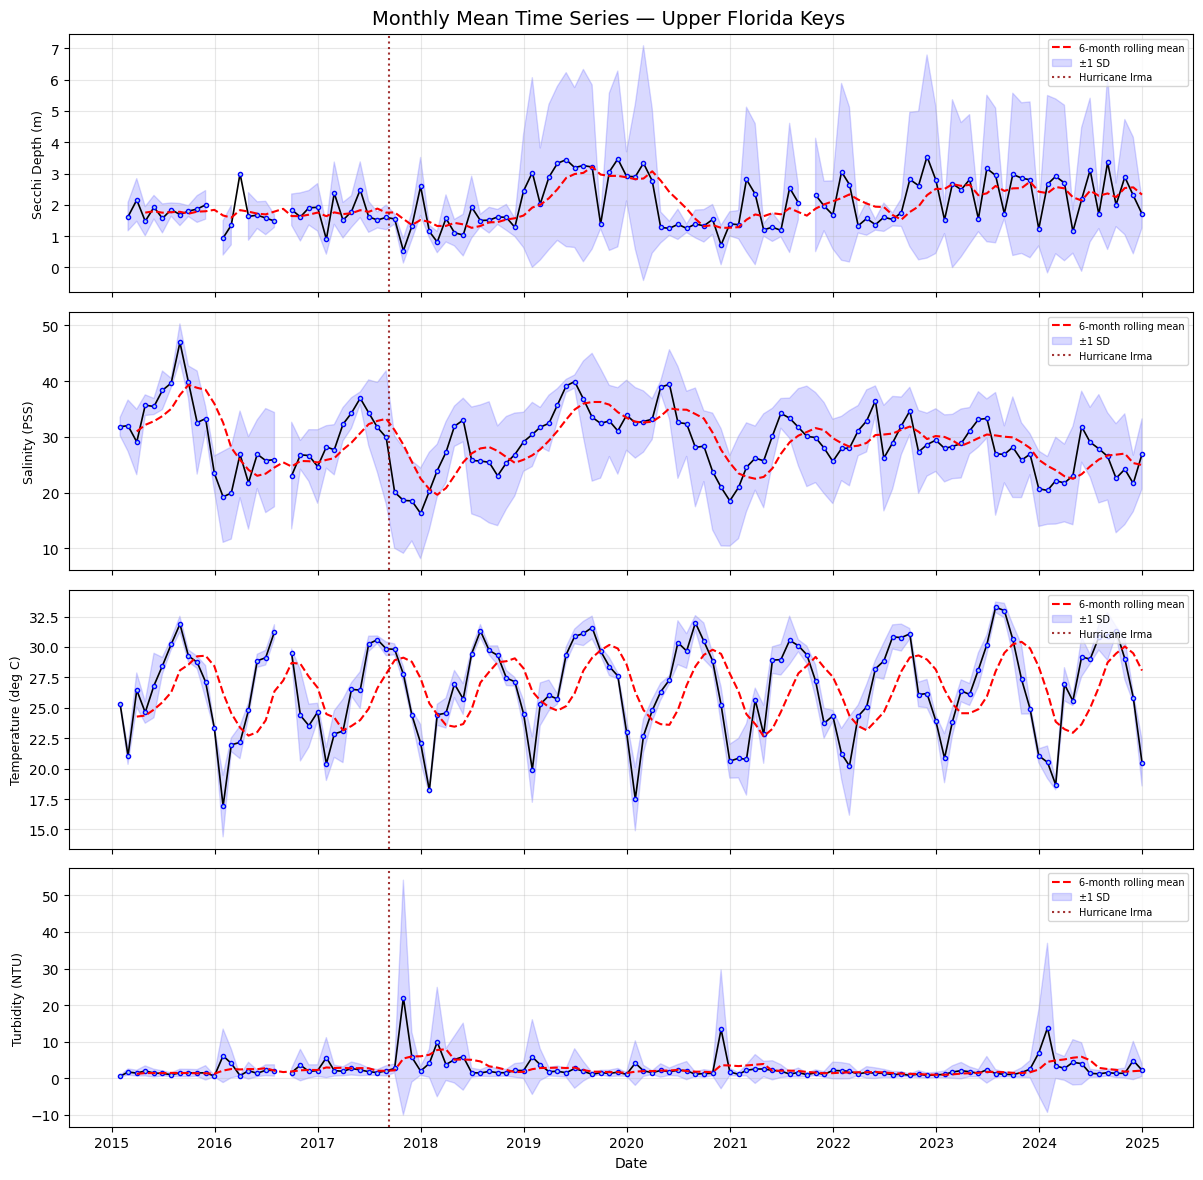

In [55]:
fig, axes = plt.subplots(len(param_cols), 1, figsize=(12, 3 * len(param_cols)), sharex=True)

for i, col in enumerate(param_cols):
    # Compute mean and std from the same resampling operation
    monthly_mean = wq_gdf[col].resample("ME").mean()
    monthly_std  = wq_gdf[col].resample("ME").std()

    axes[i].plot(monthly_mean.index, monthly_mean, linewidth=1.2,
                 color='black', marker='o', markersize=3,
                 markerfacecolor='lightblue', markeredgecolor='blue')

    # Rolling 6-month mean
    rolling = monthly_mean.rolling(window=6, min_periods=3).mean()
    axes[i].plot(monthly_mean.index, rolling, linewidth=1.5,
                 color='red', linestyle='--', label='6-month rolling mean')

    # ±1 SD band
    axes[i].fill_between(monthly_mean.index,
                          monthly_mean - monthly_std,
                          monthly_mean + monthly_std,
                          alpha=0.15, color='blue', label='±1 SD')

    # Hurricane Irma marker
    axes[i].axvline(pd.Timestamp("2017-09-10"), color="darkred",
                    linewidth=1.5, linestyle=":", alpha=0.8,
                    label="Hurricane Irma")

    axes[i].set_ylabel(col, fontsize=9)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(fontsize=7, loc='upper right')

axes[-1].set_xlabel("Date")
fig.suptitle("Monthly Mean Time Series — Upper Florida Keys", fontsize=14)
plt.tight_layout()
plt.savefig("time_series.png", dpi=150)
plt.show()

### Dual Time Series

- Secchi Depth (WQ) + NDWI (Spectral) — water clarity \
- Secchi Depth (WQ) + NDAVI (Spectral) — seagrass response

Monthly mean water quality parameters (left axis, blue) plotted alongside corresponding spectral indices (right axis, green). Dashed lines show 6-month rolling means. The red dotted vertical line marks Hurricane Irma landfall (September 10, 2017).

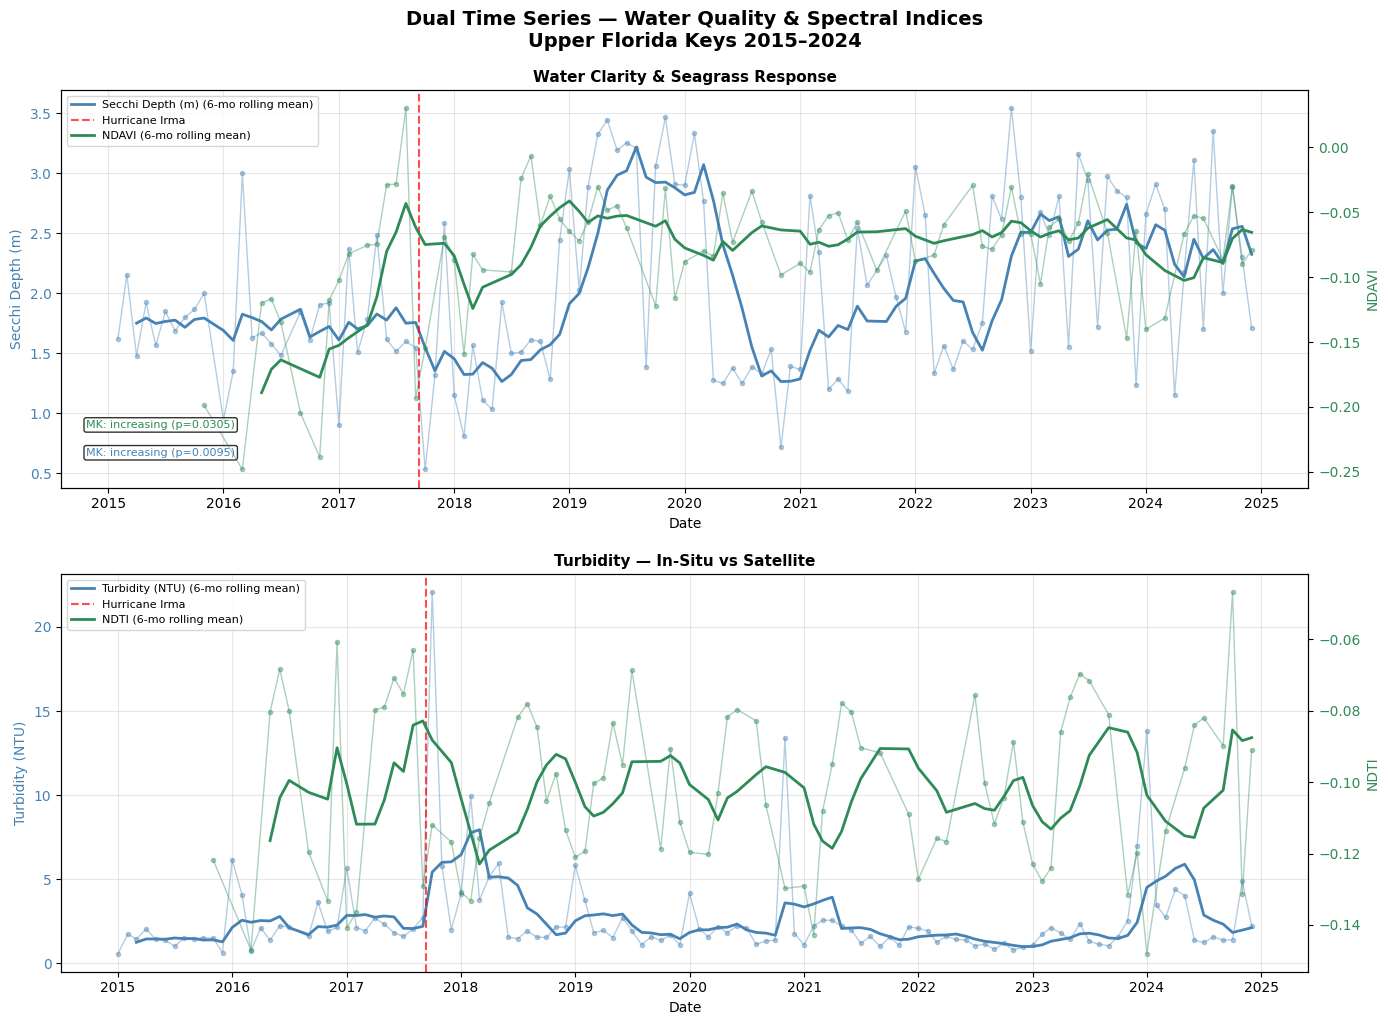

In [45]:
dual_pairs = [
    ("Secchi Depth (m)", "NDAVI", "Water Clarity & Seagrass Response"),
    ("Turbidity (NTU)",  "NDTI",  "Turbidity — In-Situ vs Satellite"),
]

fig, axes = plt.subplots(len(dual_pairs), 1, figsize=(14, 5 * len(dual_pairs)))

for i, (wq_col, spec_col, title) in enumerate(dual_pairs):
    ax1 = axes[i]
    ax2 = ax1.twinx()

    # WQ — left axis
    wq_series  = df_wq_monthly[wq_col].dropna()
    wq_rolling = wq_series.rolling(6, min_periods=3).mean()

    ax1.plot(wq_series.index, wq_series, color="steelblue",
             linewidth=1, alpha=0.4, marker="o", markersize=3)
    ax1.plot(wq_rolling.index, wq_rolling, color="steelblue",
             linewidth=2, label=f"{wq_col} (6-mo rolling mean)")
    ax1.set_ylabel(wq_col, color="steelblue", fontsize=10)
    ax1.tick_params(axis="y", labelcolor="steelblue")

    # Spectral — right axis
    spec_series  = df_spec_monthly[spec_col].dropna()
    spec_rolling = spec_series.rolling(6, min_periods=3).mean()

    ax2.plot(spec_series.index, spec_series, color="seagreen",
             linewidth=1, alpha=0.4, marker="o", markersize=3)
    ax2.plot(spec_rolling.index, spec_rolling, color="seagreen",
             linewidth=2, label=f"{spec_col} (6-mo rolling mean)")
    ax2.set_ylabel(spec_col, color="seagreen", fontsize=10)
    ax2.tick_params(axis="y", labelcolor="seagreen")

    # Hurricane Irma marker
    ax1.axvline(pd.Timestamp("2017-09-10"), color="red", linewidth=1.5,
                linestyle="--", alpha=0.7, label="Hurricane Irma")

    # Trend annotations for significant results
    mk_wq   = df_mk_wq[df_mk_wq["Parameter"] == wq_col]
    mk_spec = df_mk_spec[df_mk_spec["Index"] == spec_col]

    if not mk_wq.empty and mk_wq.iloc[0]["Significant"]:
        ax1.annotate(f"MK: {mk_wq.iloc[0]['Trend']} (p={mk_wq.iloc[0]['p-value']})",
                    xy=(0.02, 0.08), xycoords="axes fraction",
                    fontsize=8, color="steelblue",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

    if not mk_spec.empty and mk_spec.iloc[0]["Significant"]:
        ax2.annotate(f"MK: {mk_spec.iloc[0]['Trend']} (p={mk_spec.iloc[0]['p-value']})",
                    xy=(0.02, 0.15), xycoords="axes fraction",
                    fontsize=8, color="seagreen",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8))

    # Combined legend
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc="upper left", fontsize=8)

    ax1.set_title(title, fontsize=11, fontweight="bold")
    ax1.grid(True, alpha=0.3)
    ax1.set_xlabel("Date")

fig.suptitle("Dual Time Series — Water Quality & Spectral Indices\nUpper Florida Keys 2015–2024",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.subplots_adjust(top=0.94)
plt.savefig("dual_time_series.png", dpi=150, bbox_inches="tight")
plt.show()

### Anamoly Plot
Monthly deviations from the 2015–2024 long-term mean for Secchi Depth and NDAVI. Bars above zero indicate above-average conditions, bars below indicate below-average. The synchronized shift from predominantly negative (red) to positive (green/blue) anomalies in both panels after 2018 visually confirms the improving trend detected by Mann-Kendall.

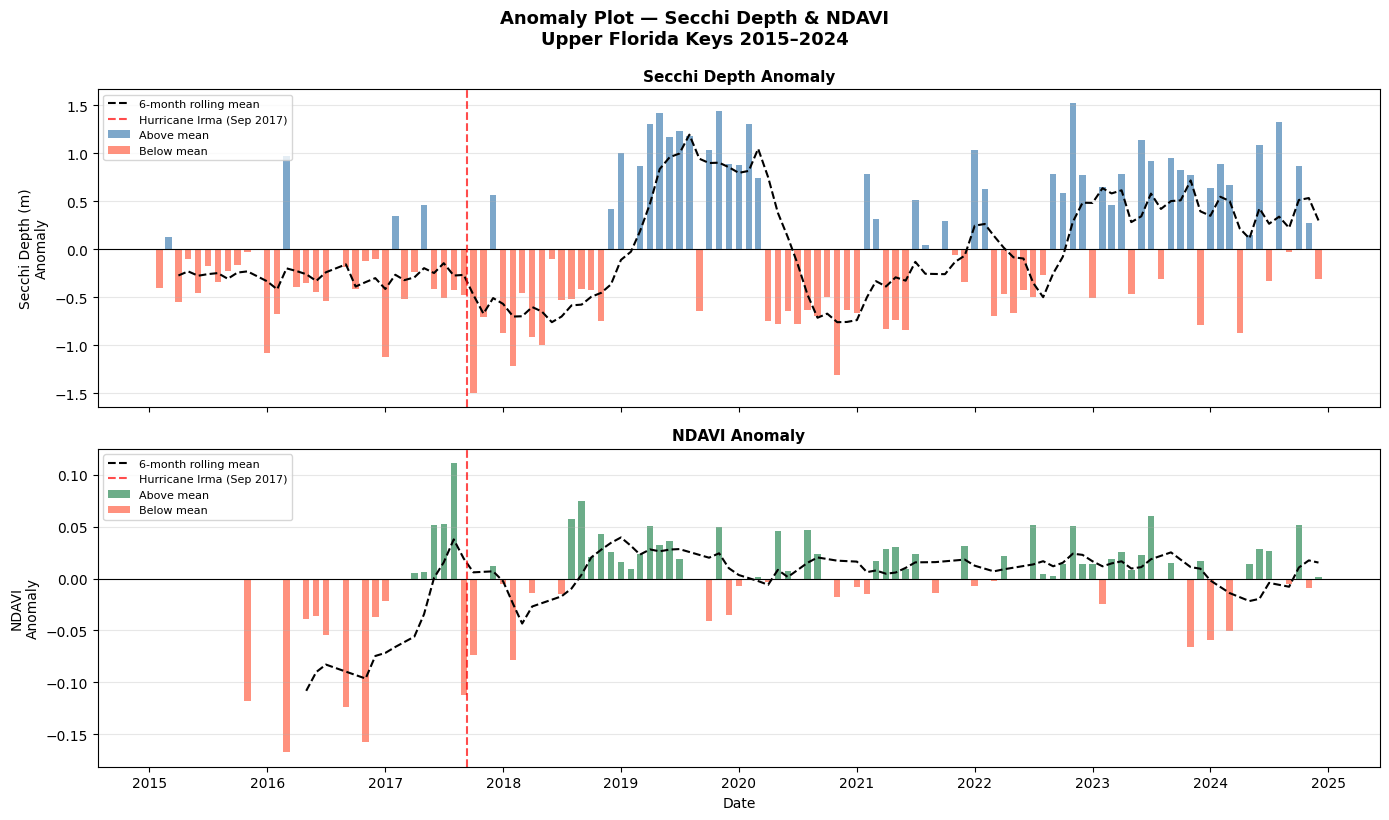

In [48]:

# FIGURE — Anomaly Plot
# Secchi Depth and NDAVI deviations from long-term mean


fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

pairs = [
    (df_wq_monthly,   "Secchi Depth (m)", "steelblue",  "Secchi Depth Anomaly"),
    (df_spec_monthly, "NDAVI",            "seagreen",   "NDAVI Anomaly"),
]

for i, (df, col, color, title) in enumerate(pairs):
    ax = axes[i]
    series = df[col].dropna()

    # Compute anomaly
    mean   = series.mean()
    anomaly = series - mean

    # Color bars by positive/negative
    pos = anomaly.clip(lower=0)
    neg = anomaly.clip(upper=0)

    ax.bar(anomaly.index, pos, color=color, alpha=0.7, width=20, label="Above mean")
    ax.bar(anomaly.index, neg, color="tomato", alpha=0.7, width=20, label="Below mean")

    # Rolling mean of anomaly
    rolling = anomaly.rolling(6, min_periods=3).mean()
    ax.plot(anomaly.index, rolling, color="black", linewidth=1.5,
            linestyle="--", label="6-month rolling mean")

    # Zero line
    ax.axhline(0, color="black", linewidth=0.8, linestyle="-")

    # Hurricane Irma
    ax.axvline(pd.Timestamp("2017-09-10"), color="red", linewidth=1.5,
               linestyle="--", alpha=0.7, label="Hurricane Irma (Sep 2017)")

    ax.set_ylabel(f"{col}\nAnomaly", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.grid(True, alpha=0.3, axis="y")
    ax.legend(fontsize=8, loc="upper left")

axes[-1].set_xlabel("Date", fontsize=10)
fig.suptitle("Anomaly Plot — Secchi Depth & NDAVI\nUpper Florida Keys 2015–2024",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig("anomaly_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### WQ — Spectral Scatter Plots
Bivariate scatter plots for six ecologically significant parameter-index pairs, colored by year. 



 - Turbidity vs NDTI:  Both measure water turbidity — in-situ sensor vs satellite, used for cross-validation |
 - Turbidity vs NDWI:  Tests whether satellite water index responds to suspended particle load |
-  Secchi Depth vs NDWI:  Both capture water clarity — tests agreement between in-situ and satellite measurement |
 - Secchi Depth vs NDVI:  Tests whether overall vegetation greenness responds to light availability |
  - **Secchi Depth vs NDAVI**: Seagrass requires light to photosynthesize; clearer water allows more light to reach the seafloor, supporting denser seagrass growth detectable by NDAVI |
 - Salinity vs NDAVI:  Tests whether salinity gradients across the estuary influence submerged vegetation distribution || Pair | Ecological Rationale |


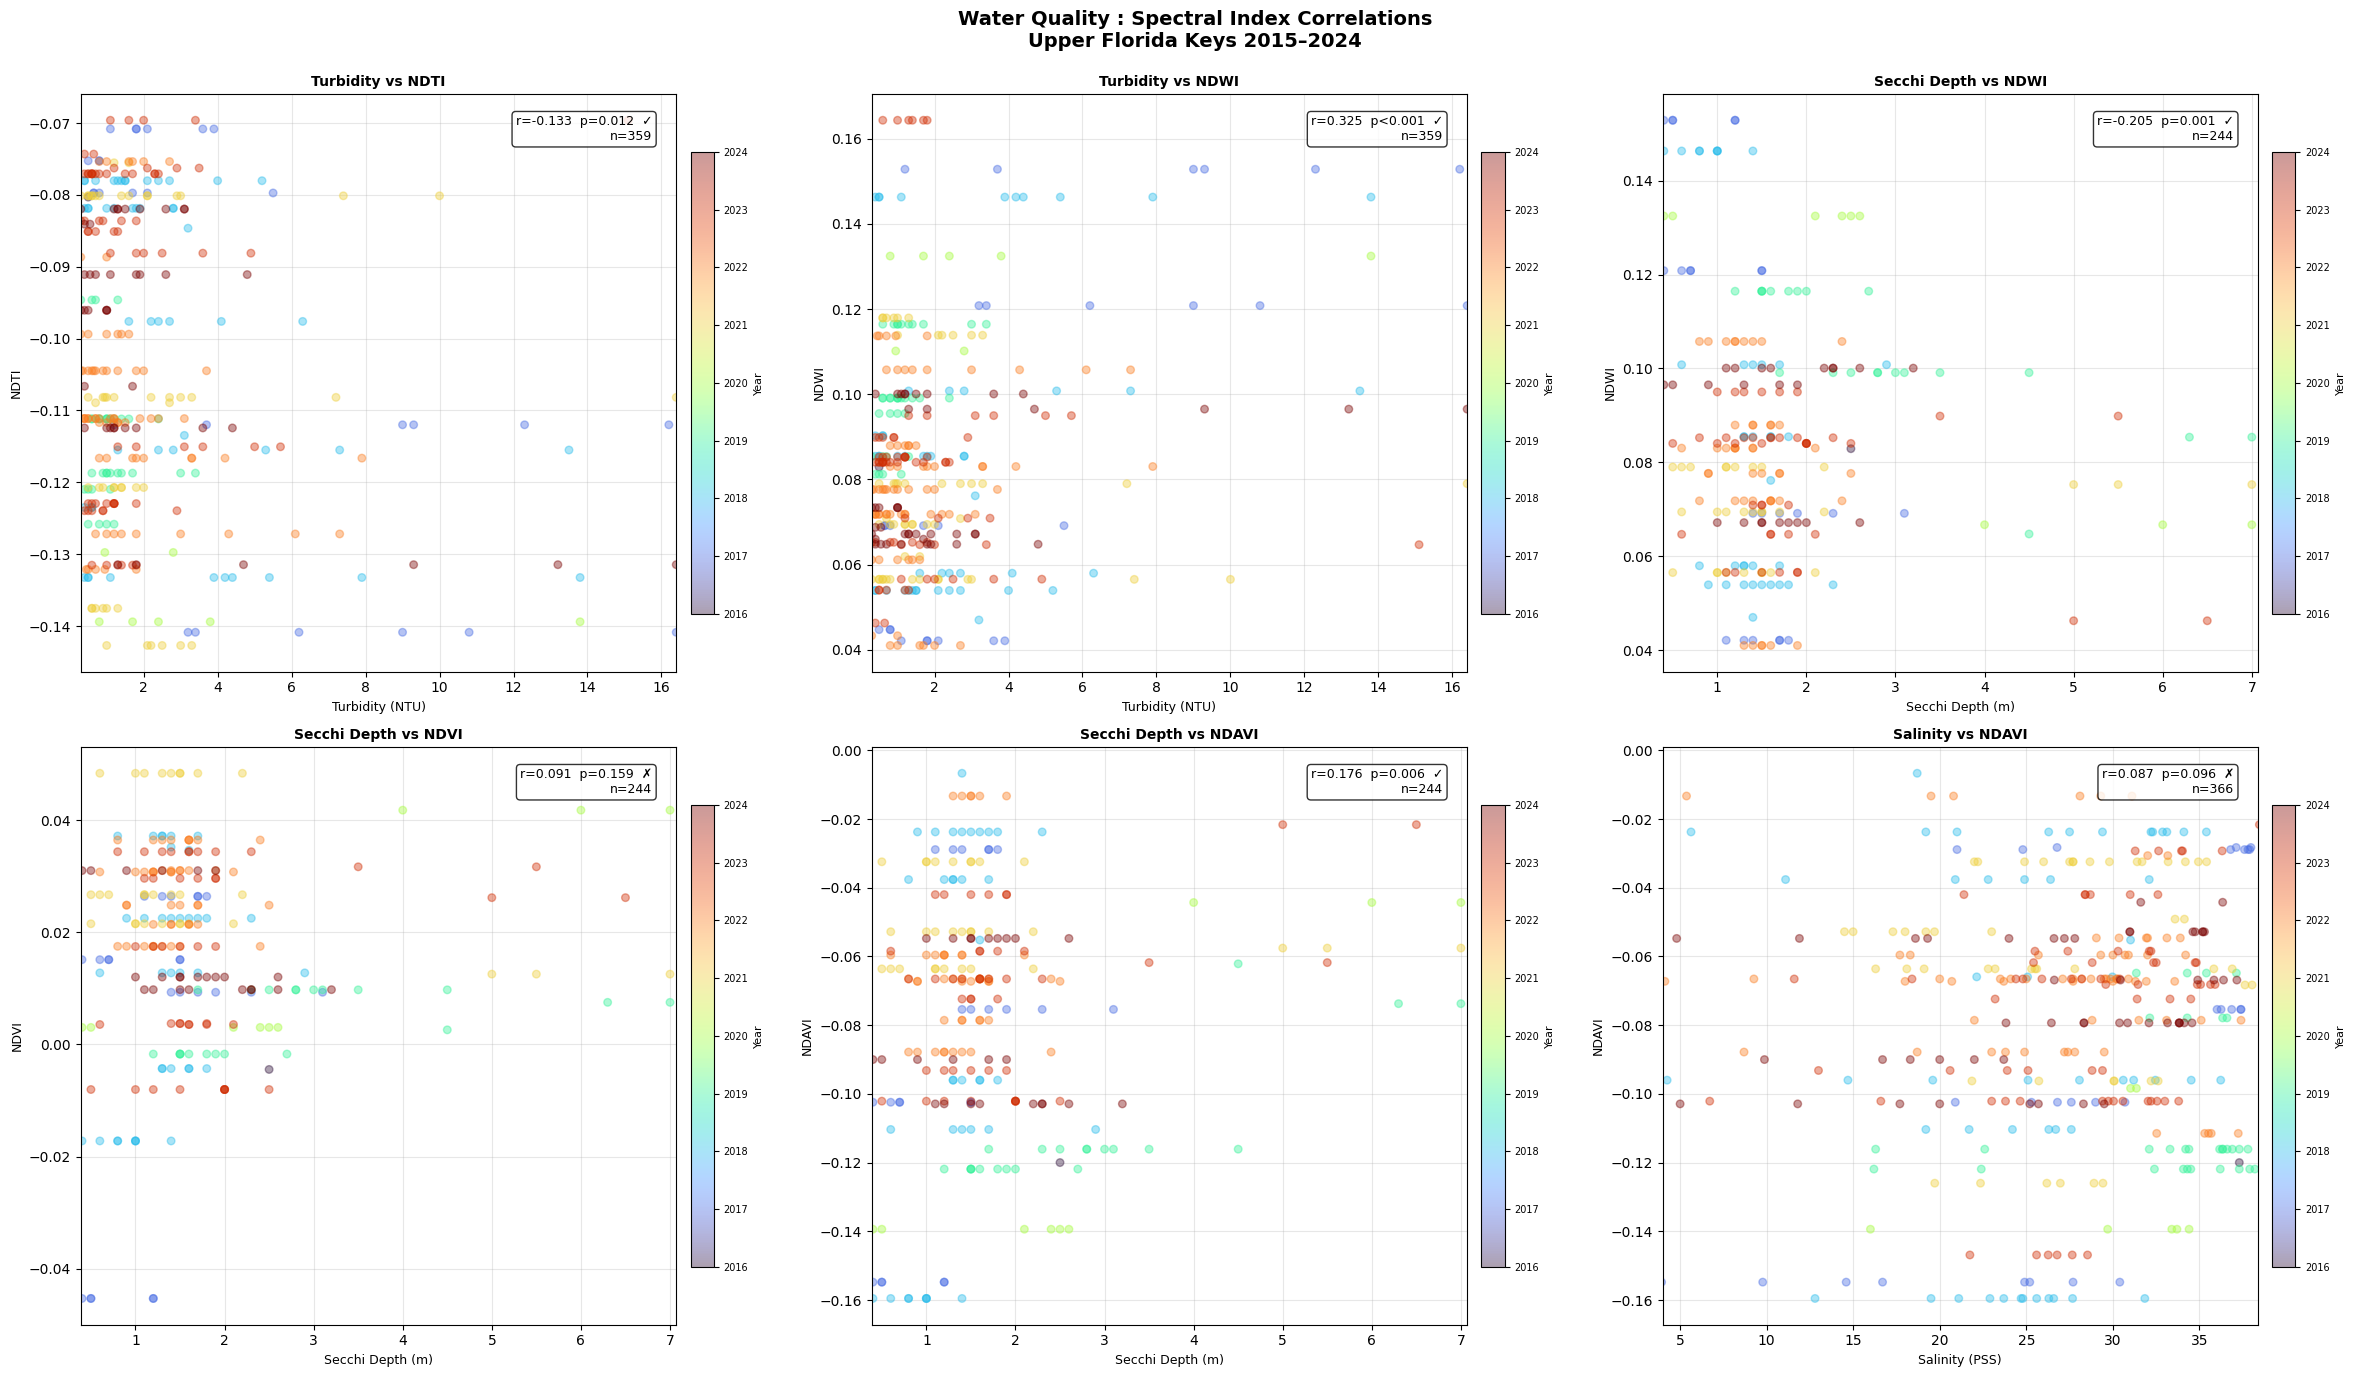

In [56]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

for i, (wq_col, spec_col, label) in enumerate(pair_cols):
    ax = axes[i]
    paired = df_matched[[wq_col, spec_col]].dropna()
    x = paired[wq_col]
    y = paired[spec_col]

    # Compute regression INSIDE the loop
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_start, x_end = x.min(), x.max()
    y_start = slope * x_start + intercept
    y_end   = slope * x_end   + intercept

    # Scatter colored by year
    years = paired.index.year
    scatter = ax.scatter(x, y, c=years, cmap="turbo",
                        alpha=0.4, s=30, zorder=2)

    # Only draw arrow if significant
    if p < 0.05:
        ax.annotate("",
                    xy=(x_end, y_end),
                    xytext=(x_start, y_start),
                    arrowprops=dict(arrowstyle="-|>", color="black", lw=1.0),
                    zorder=3)

    # Correlation annotation
    p_str = "p<0.001" if p < 0.001 else f"p={p:.3f}"
    sig_str = "✓" if p < 0.05 else "✗"
    ax.annotate(f"r={r:.3f}  {p_str}  {sig_str}\nn={len(paired)}",
                xy=(0.96, 0.92), xycoords="axes fraction",
                fontsize=9, color="black",
                ha="right",
                bbox=dict(boxstyle="round,pad=0.3",
                         facecolor="white", alpha=0.8))

    ax.set_xlabel(wq_col, fontsize=9)
    ax.set_ylabel(spec_col, fontsize=9)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlim(x.quantile(0.02), x.quantile(0.98))
    ax.grid(True, alpha=0.3)

    cbar = fig.colorbar(scatter, ax=ax, pad=0.02, shrink=0.8)
    cbar.set_label("Year", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Water Quality : Spectral Index Correlations\nUpper Florida Keys 2015–2024",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig("wq_spectral_correlations.png", dpi=150, bbox_inches="tight")
plt.show()

#### Cross-Correlation Matrix
Pearson correlation coefficients between all water quality parameters and spectral indices, computed from 387 matched pairs. Checkmarks (✓) indicate statistically significant relationships (p<0.05). Color scale runs from red (strong negative) to blue (strong positive).

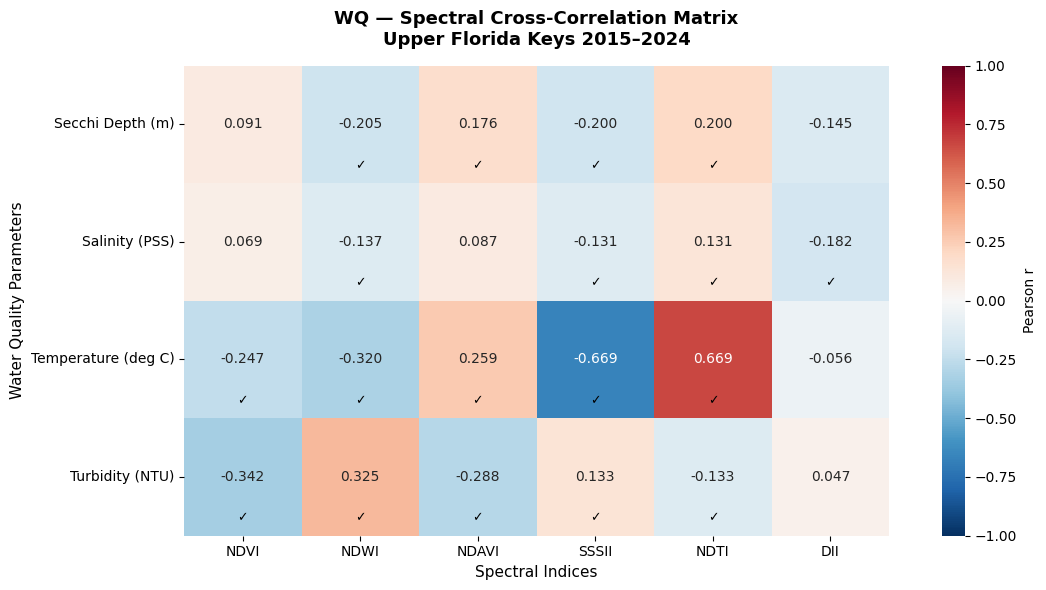

In [52]:
# FIGURE — WQ vs Spectral Cross-Correlation Heatmap

# Build cross-correlation matrix from matched pairs
cross_corr = pd.DataFrame(index=wq_cols, columns=spectral_cols, dtype=float)
cross_pval = pd.DataFrame(index=wq_cols, columns=spectral_cols, dtype=float)

for wq_col in wq_cols:
    for spec_col in spectral_cols:
        paired = df_matched[[wq_col, spec_col]].dropna()
        df_matched = df_matched.replace([np.inf, -np.inf], np.nan)
        if len(paired) >= 10:
            r, p = stats.pearsonr(paired[wq_col], paired[spec_col])
            cross_corr.loc[wq_col, spec_col] = round(r, 3)
            cross_pval.loc[wq_col, spec_col] = p
        else:
            cross_corr.loc[wq_col, spec_col] = np.nan
            cross_pval.loc[wq_col, spec_col] = np.nan

# ---------------------------
# Plot
# ---------------------------
fig, ax = plt.subplots(figsize=(12, 6))

sns.heatmap(cross_corr.astype(float),
            annot=True, fmt=".3f",
            cmap="RdBu_r", center=0,
            vmin=-1, vmax=1,
            linewidths=0,
            square=True,
            ax=ax,
            annot_kws={"size": 10})

# Overlay significance stars
for i, wq_col in enumerate(wq_cols):
    for j, spec_col in enumerate(spectral_cols):
        p = cross_pval.loc[wq_col, spec_col]
        if pd.notna(p) and p < 0.05:
            ax.text(j + 0.5, i + 0.85, "✓",
                    ha="center", va="center",
                    fontsize=9, color="black", fontweight="bold")

ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)
ax.set_title("WQ — Spectral Cross-Correlation Matrix\nUpper Florida Keys 2015–2024",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Spectral Indices", fontsize=11)
ax.set_ylabel("Water Quality Parameters", fontsize=11)

# Colorbar label
cbar = ax.collections[0].colorbar
cbar.set_label("Pearson r", fontsize=10)

plt.tight_layout()
plt.savefig("cross_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

###  Summary DataFrame 

In [54]:
summary = pd.DataFrame([
    # Mann-Kendall WQ
    {"Dataset": "In-Situ WQ",    "Variable": "Secchi Depth (m)",    "Test": "Mann-Kendall", "Trend": "Increasing", "Tau": 0.1631,  "p-value": 0.0095, "Significant": "✓"},
    {"Dataset": "In-Situ WQ",    "Variable": "Salinity (PSS)",       "Test": "Mann-Kendall", "Trend": "No trend",   "Tau": -0.1067, "p-value": 0.0858, "Significant": "✗"},
    {"Dataset": "In-Situ WQ",    "Variable": "Temperature (deg C)",  "Test": "Mann-Kendall", "Trend": "No trend",   "Tau": 0.0591,  "p-value": 0.3417, "Significant": "✗"},
    {"Dataset": "In-Situ WQ",    "Variable": "Turbidity (NTU)",      "Test": "Mann-Kendall", "Trend": "No trend",   "Tau": -0.0591, "p-value": 0.3417, "Significant": "✗"},
    # Mann-Kendall Spectral
    {"Dataset": "Sentinel-2",    "Variable": "NDVI",                 "Test": "Mann-Kendall", "Trend": "Increasing", "Tau": 0.1531,  "p-value": 0.0409, "Significant": "✓"},
    {"Dataset": "Sentinel-2",    "Variable": "NDWI",                 "Test": "Mann-Kendall", "Trend": "No trend",   "Tau": -0.1396, "p-value": 0.0623, "Significant": "✗"},
    {"Dataset": "Sentinel-2",    "Variable": "NDAVI",                "Test": "Mann-Kendall", "Trend": "Increasing", "Tau": 0.1619,  "p-value": 0.0305, "Significant": "✓"},
    {"Dataset": "Sentinel-2",    "Variable": "SSSII",                "Test": "Mann-Kendall", "Trend": "No trend",   "Tau": -0.0203, "p-value": 0.7891, "Significant": "✗"},
    {"Dataset": "Sentinel-2",    "Variable": "NDTI",                 "Test": "Mann-Kendall", "Trend": "No trend",   "Tau": 0.0203,  "p-value": 0.7891, "Significant": "✗"},
    {"Dataset": "Sentinel-2",    "Variable": "DII",                  "Test": "Mann-Kendall", "Trend": "No trend",   "Tau": 0.1517,  "p-value": 0.1517, "Significant": "✗"},
    # Key correlations
    {"Dataset": "WQ × Spectral", "Variable": "Turbidity vs NDTI",   "Test": "Pearson r",    "Trend": "Negative",   "Tau": -0.133,  "p-value": 0.0119, "Significant": "✓"},
    {"Dataset": "WQ × Spectral", "Variable": "Turbidity vs NDWI",   "Test": "Pearson r",    "Trend": "Positive",   "Tau": 0.325,   "p-value": 0.0000, "Significant": "✓"},
    {"Dataset": "WQ × Spectral", "Variable": "Secchi vs NDWI",      "Test": "Pearson r",    "Trend": "Negative",   "Tau": -0.205,  "p-value": 0.0013, "Significant": "✓"},
    {"Dataset": "WQ × Spectral", "Variable": "Secchi vs NDAVI",     "Test": "Pearson r",    "Trend": "Positive",   "Tau": 0.176,   "p-value": 0.0059, "Significant": "✓"},
    {"Dataset": "WQ × Spectral", "Variable": "Temperature vs SSSII","Test": "Pearson r",    "Trend": "Negative",   "Tau": -0.669,  "p-value": 0.0000, "Significant": "✓"},
    {"Dataset": "WQ × Spectral", "Variable": "Temperature vs NDTI", "Test": "Pearson r",    "Trend": "Positive",   "Tau": 0.669,   "p-value": 0.0000, "Significant": "✓"},
])

# Style significant rows
def highlight_sig(row):
    if row["Significant"] == "✓" and row["Trend"] in ["Increasing", "Positive"]:
        return ["background-color: #c8e6c9"] * len(row)
    elif row["Significant"] == "✓" and row["Trend"] in ["Decreasing", "Negative"]:
        return ["background-color: #ffcdd2"] * len(row)
    elif row["Significant"] == "✓":
        return ["background-color: #fff9c4"] * len(row)
    else:
        return [""] * len(row)

display(summary.style.apply(highlight_sig, axis=1).hide(axis="index"))

Dataset,Variable,Test,Trend,Tau,p-value,Significant
In-Situ WQ,Secchi Depth (m),Mann-Kendall,Increasing,0.163100,0.009500,✓
In-Situ WQ,Salinity (PSS),Mann-Kendall,No trend,-0.106700,0.085800,✗
In-Situ WQ,Temperature (deg C),Mann-Kendall,No trend,0.059100,0.341700,✗
In-Situ WQ,Turbidity (NTU),Mann-Kendall,No trend,-0.059100,0.341700,✗
Sentinel-2,NDVI,Mann-Kendall,Increasing,0.153100,0.040900,✓
Sentinel-2,NDWI,Mann-Kendall,No trend,-0.139600,0.062300,✗
Sentinel-2,NDAVI,Mann-Kendall,Increasing,0.161900,0.030500,✓
Sentinel-2,SSSII,Mann-Kendall,No trend,-0.020300,0.789100,✗
Sentinel-2,NDTI,Mann-Kendall,No trend,0.020300,0.789100,✗
Sentinel-2,DII,Mann-Kendall,No trend,0.151700,0.151700,✗


## Summary

This notebook integrates in-situ water quality data with Sentinel-2 derived 
spectral indices to perform trend and correlation analysis across 2015–2024 for the Upper Florida Keys region.

**Approach:**
- Section 1: Mann-Kendall trend analysis on full WQ monthly time series (119 months)
- Section 2: Mann-Kendall trend analysis on full spectral index time series (83 months)
- Section 3: Cross-correlation analysis on 387 matched pairs (±3 day tolerance)

**Spectral merge:**
- 145 cloud-free Sentinel-2 scenes (L2A 2017–2024, L1C 2015–2016)
- 22% match rate with WQ observations using 3-day tolerance window
- EVI excluded (143/145 NaN values — unsuitable over water)
- Note: 2015–2016 L1C scenes processed without SCL cloud masking

**Key findings:**

| Dataset | Parameter | Trend | p-value |
|---------|-----------|-------|---------|
| WQ | Secchi Depth | Increasing ↑ | 0.009 |
| Spectral | NDVI | Increasing ↑ | 0.041 |
| Spectral | NDAVI | Increasing ↑ | 0.031 |

- Water clarity has improved significantly over 2015–2024
- Seagrass spectral signal has increased over the same period
- Clearer water significantly correlates with stronger seagrass signal (r=0.176, p=0.006)
- Temperature shows strong seasonal coupling with SSSII/NDTI (r=±0.669)
- Anomaly plot suggests Hurricane Irma (Sep 2017) as a potential turning point 
  in both datasets, with predominantly positive anomalies in both Secchi Depth 
  and NDAVI following the disturbance event

**Figures produced:**
- `cross_correlation_heatmap.png` — WQ vs spectral Pearson r matrix
- `wq_spectral_correlations.png` — scatter plots for key pairs colored by year
- `dual_time_series.png` — paired WQ and spectral time series with rolling means
- `anomaly_plot.png` — monthly anomalies for Secchi Depth and NDAVI